In [1]:
import yaml
cfg_scenarios = yaml.safe_load(open('../config/scenarios_bcnexus.yaml'))['SCENARIOS']
scenarios=set(cfg_scenarios.keys())

In [2]:
scenarios

{'Base_CNZ',
 'Base_CNZ_noCCS',
 'CNZ_LIMITED_CO2',
 'CNZ_LIMITED_CO2_PTY',
 'IMP_USA_100',
 'NUC_standard_2028',
 'NUC_standard_2028_2xCost',
 'NUC_standard_2030',
 'NUC_standard_2030_2xCost',
 'NUC_standard_2035',
 'NUC_standard_2035_2xCost',
 'NUC_standard_2035_4xCost'}

In [3]:
check_scene='Base_CNZ_noCCS'
LP_PATH = f"../data/clews_data/clews_build_data/Model_Kotzur/{check_scene}/{check_scene}.lp"

In [4]:
# import gurobipy as gp
# m = gp.read(LP_PATH)  # or export via otoole/your preprocessor
   # scan for |coef| < 1e-6 and > 1e5, group by constraint prefix

**The underlying problem**

- The barrier method solves linear systems built from your constraint matrix at every iteration; 
- when one matrix mixes numbers like 9e-9 and 1e6, floating-point arithmetic loses the small numbers inside the large ones, the iterates drift, and you get exactly the stall your log shows. 
- Every table in the scanner exists to answer one question: __which physical quantity, in which equation, is written in the wrong units?__

In [ ]:
from bcnexus.scan_coeff import scan, family_table
r = scan(LP_PATH)

Set parameter Username
Set parameter LicenseID to value 2812656


__How to read each table, in order__
----

### 1. Summary
confirms the disease. You already know the answer here (14 orders in the matrix). Its only job is to verify after a fix attempt that the range actually shrank. Target: get every component under ~6 orders. This is your before/after metric.

In [7]:
r["summary"]                     # confirms the 14-order matrix range from your log

,component,min_abs,max_abs,orders
0,matrix,7.260270e-07,100000.0,11.139047
1,objective,5.737824e-06,17699823.0,12.489222
2,rhs,1.000000e-05,100000000.0,13.000000


### 2. Row Spread

— finds the lethal rows. 
> Global range is a symptom; within-row spread is the mechanism. Gurobi can rescale rows and columns independently, so a matrix where the water rows are all ~1e-9 and the energy rows all ~1e0 is actually fine — scaling fixes it. What scaling cannot fix is a single equation containing both a 1e-9 and a 1e6 coefficient, because one scale factor per row cannot shrink one entry and grow another. So look at the top of row_spread:

If the worst rows have spread > ~1e8 and they share a family name, that family is our target. We'll likely see one family dominate — my expectation for a CLEWs model is an energy-balance or activity constraint where water (m³-scale) and energy (PJ-scale) meet in the same row.

If spreads are all below ~1e6, the ill-conditioning is between rows, not within them, and the fix is easier: rescale whole variable families (change of units), not individual coefficients.

In [8]:
r["row_spread"].head(20)         # worst-conditioned individual constraints

,row_name,row_family,min_abs,max_abs,spread
0,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
1,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
2,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
3,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
4,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
5,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
6,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
7,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
8,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0
9,"CC1_UndiscountedCapitalInvestment(REGION1,BATT...",CC1_UndiscountedCapitalInvestment,1.0,100000.0,100000.0


### 3. The Family Table (matrix)

— names the culprit. This tells you which (constraint family × variable family) pairs carry the flagged entries and how many. The interpretation key:

Constraint family maps to an OSeMOSYS equation (EBa* = energy balance, CAa* = capacity adequacy, E1–E8 = emissions, and your CLEWs extensions for land/water).
Variable family × constraint family maps to a parameter. A tiny coefficient in an EBa row against RateOfActivity comes from InputActivityRatio or OutputActivityRatio. A huge one in a CAa row comes from CapacityToActivityUnit. In emission rows, EmissionActivityRatio.

That mapping is the whole point: the scanner converts "solver had numerical trouble" into "OutputActivityRatio for water technologies is six orders too small," which is a fixable data statement.

In [9]:
family_table(r["matrix"])        # which parameter families carry the extremes

,row_family,col_family,side,n,min_abs,max_abs
0,EBa11_EnergyBalanceEachTS5,RateOfActivity,small,360,7.260270e-07,9.041100e-07
1,EBb4_EnergyBalanceEachYear4,RateOfActivity,small,360,7.260270e-07,9.041100e-07



### 4. Objective and Bounds

— the big-M hunt. These are independent of the matrix issue. A 2e8 objective coefficient is either a legitimate cost in the wrong monetary unit ($ instead of M$) or a penalty someone set to "a big number." A 1e8 finite bound is a fake infinity. Both are one-line fixes and both degrade barrier convergence, so clean them regardless of what the matrix scan shows.

In [10]:
r["bounds"]                      # hidden big-M values in variable bounds

,col_name,col_family,which,bound


In [11]:
r["objective"].head(20)          # the 2e8 cost coefficients

,col_name,col_family,coef,abs_coef,side
0,"NewStorageCapacity(REGION1,HYDRODAM01,2021)",NewStorageCapacity,1.769982e+07,1.769982e+07,large
1,"NewStorageCapacity(REGION1,HYDRODAM01,2022)",NewStorageCapacity,1.685697e+07,1.685697e+07,large
2,"NewStorageCapacity(REGION1,HYDRODAM01,2023)",NewStorageCapacity,1.605426e+07,1.605426e+07,large
3,"NewStorageCapacity(REGION1,HYDRODAM01,2024)",NewStorageCapacity,1.528977e+07,1.528977e+07,large
4,"NewStorageCapacity(REGION1,HYDRODAM01,2025)",NewStorageCapacity,1.456169e+07,1.456169e+07,large
5,"NewStorageCapacity(REGION1,HYDRODAM01,2026)",NewStorageCapacity,1.386827e+07,1.386827e+07,large
6,"NewStorageCapacity(REGION1,HYDRODAM01,2027)",NewStorageCapacity,1.320788e+07,1.320788e+07,large
7,"NewStorageCapacity(REGION1,HYDRODAM01,2028)",NewStorageCapacity,1.257893e+07,1.257893e+07,large
8,"NewStorageCapacity(REGION1,HYDRODAM01,2029)",NewStorageCapacity,1.197994e+07,1.197994e+07,large
9,"NewStorageCapacity(REGION1,HYDRODAM01,2030)",NewStorageCapacity,1.140946e+07,1.140946e+07,large


### 5. Exact values as forensics

Once you have an exemplar coefficient, factor it. 2.78e-7 is 1/3.6e6 — a kWh↔PJ chain applied where it shouldn't be. 3.17e-8 ≈ 1/(365×86400) — an annual-to-per-second conversion. The mantissa usually reconstructs the erroneous conversion for you.
The decision rule that follows

Within-row spread dominated by one or two families → rescale those parameters in the input data (change the unit the ratio is expressed in), regenerate, rerun.
Spread distributed but between-row → rescale variable units globally (money to M$, water to Mm³ or dam³, activity to PJ) so all families land near 1e-2..1e2.
Big objective/bounds entries → replace fake infinities with GRB.INFINITY (i.e., remove the bound) and pull penalties down to ~10–100× the largest real cost.

After any change, one run of scan() on the regenerated model: if summary still shows >8 orders anywhere, you missed a family.

,row_name,col_name,row_family,col_family,coef,abs_coef,side
2,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2043)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
3,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2044)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
4,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2045)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
5,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2046)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
6,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2047)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
7,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2048)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
8,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2049)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
9,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2050)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
12,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2027)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small
13,"EBa11_EnergyBalanceEachTS5(REGION1,18,LND4PWR,...","RateOfActivity(REGION1,18,PWRURNB01,1,2028)",EBa11_EnergyBalanceEachTS5,RateOfActivity,-7.260270e-07,7.260270e-07,small


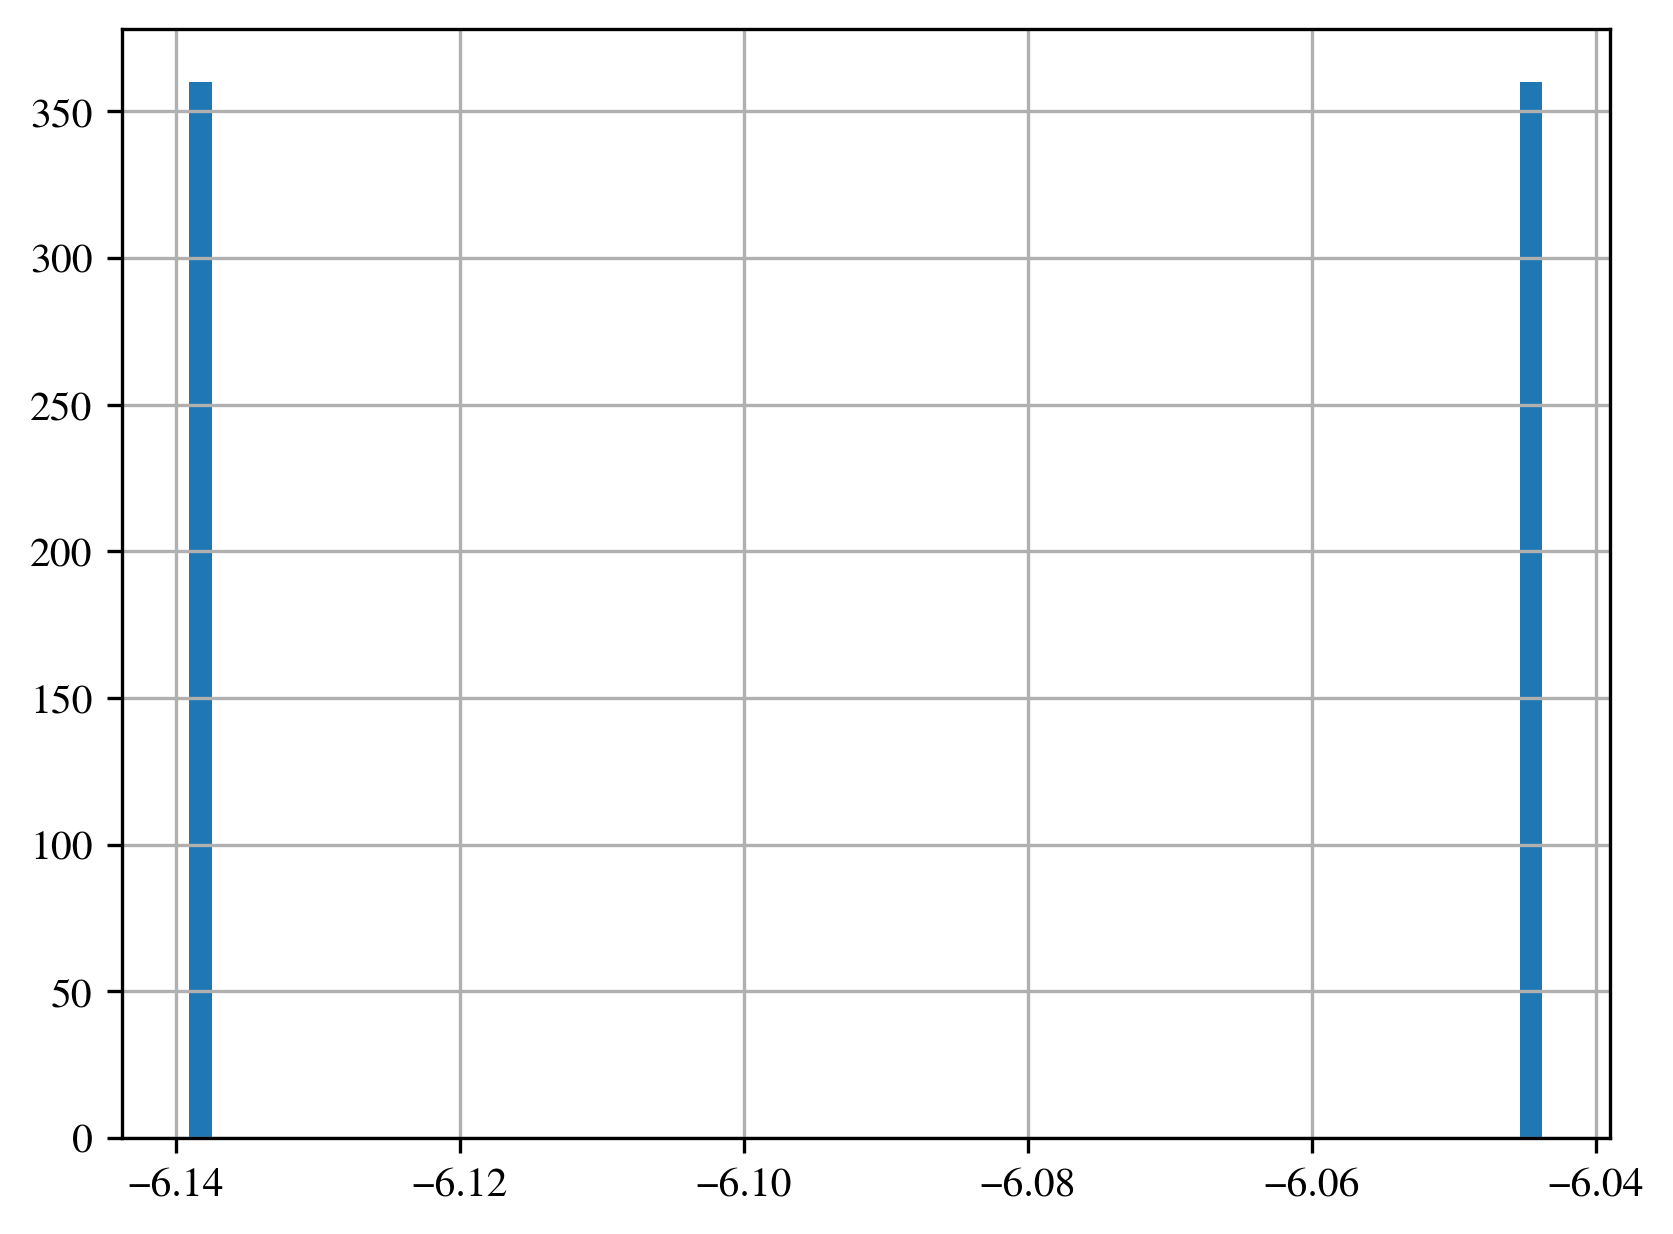

In [12]:
# distribution of flagged coefficients, log scale
import numpy as np
r["matrix"]["abs_coef"].apply(np.log10).hist(bins=60)

# trace one family pair back to concrete rows for unit diagnosis
r["matrix"].query(
    "row_family.str.contains('EBa') and col_family == 'RateOfActivity'"
).head(10)